
<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



<div style="border: 2px solid green; padding: 10px; border-radius: 5px;">
Reviewer's comment v2: Overall Feedback
Hello Michael,

My name is Mixo (https://hub.tripleten.com/u/290771b5). Congratulations on submitting your practical project! 🎉

Final Decision: Approved ✅

Excellent work!

You’ve successfully met all project requirements, and your implementation demonstrates a solid understanding of the key concepts.

You can find my more detailed notes within your project notebook in the Reviewer's comment v3: section.

Your project is approved. Keep up the great work — you’re making strong progress.

Congratulations!
</div>


# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style='whitegrid')
%matplotlib inline

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the dataset
df = pd.read_csv('/datasets/games.csv')

In [3]:
# Display basic information about the dataset
df.info()
df.head(10)
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

In [4]:
# Check for duplicate entries
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### Key Questions to Answer:
- What's the total number of records in our dataset? 16,715 records.
- What data types are present in each column? Mostly float64 and object (User_Score is object because of "tbd").
- Are there any obvious issues with the data? Yes, high missing values in critic/user scores and ratings.
- Do we see any immediate patterns or anomalies? Most games have very low sales, with a few blockbusters.

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()

In [6]:
# Verify the changes
print(df.columns.tolist())

['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice work on the setup and initial exploration: you loaded the dataset, checked schema/missing values, verified duplicates, and standardized column names with a clear verification step. The workflow here is easy to follow and well organized.

</div>


### 2.2 Data Type Conversion

In [7]:
# Check current data types
print(df.dtypes)

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object


In [8]:
# Make changes to data types if necessary
# Describe the columns where the data types have been changed and why.
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
df['user_score'] = pd.to_numeric(df['user_score'].replace('tbd', np.nan), errors='coerce')

# I changed year_of_release from float to numeric (to keep it clean) and user_score from object to float because it contained "tbd".

In [9]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.
print("I replaced 'tbd' with NaN and converted to numeric. New missing count in user_score:", df['user_score'].isna().sum())

I replaced 'tbd' with NaN and converted to numeric. New missing count in user_score: 9125


### 2.3 Handling Missing Values

In [10]:
# Examine missing values
print(df.isna().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [11]:
# Calculate percentage of missing values
missing_percent = (df.isna().sum() / len(df) * 100).round(2)
print(missing_percent)

name                0.01
platform            0.00
year_of_release     1.61
genre               0.01
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
critic_score       51.32
user_score         54.59
rating             40.48
dtype: float64


In [12]:
# Analyze patterns in missing values
print("Missing values by year (sample):")
missing_by_year = df.groupby('year_of_release')[['critic_score', 'user_score', 'rating']].apply(lambda x: x.isna().mean().round(3))
print(missing_by_year.tail(10))

Missing values by year (sample):
                 critic_score  user_score  rating
year_of_release                                  
2007.0                  0.422       0.475   0.314
2008.0                  0.499       0.537   0.313
2009.0                  0.543       0.569   0.291
2010.0                  0.602       0.628   0.363
2011.0                  0.560       0.559   0.381
2012.0                  0.508       0.481   0.456
2013.0                  0.498       0.441   0.419
2014.0                  0.551       0.434   0.406
2015.0                  0.629       0.510   0.480
2016.0                  0.538       0.478   0.442


In [13]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy
# Strategy: Drop only rows with missing name and genre (2 rows, negligible impact).
# Keep year_of_release, critic_score, user_score, and rating as NaN.
# In later steps (correlations, hypothesis tests, etc.) I filter to rows where these columns are not NaN.
df = df.dropna(subset=['name', 'genre']).reset_index(drop=True)
print("Dropped 2 rows with missing name and genre. Remaining rows:", len(df))

Dropped 2 rows with missing name and genre. Remaining rows: 16713


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You identified missingness, but the project asks you to handle missing values “based on analysis.” Right now you only drop the 2 rows with missing `name`/`genre`. Consider explicitly documenting (and reflecting in code) what your strategy is for `year_of_release`, `critic_score`, `user_score`, and `rating`—even if the decision is to keep them as NaN—and clarify how you will deal with those NaNs in later steps (e.g., filtering rows only for specific analyses that require those fields).

</div>


**Why do you think the values are missing? Give possible reasons.**

I think the values are missing because:
- Critic and User Scores are missing for many older games (before online reviews were common) and niche titles. "tbd" entries were converted to NaN because they represent scores not yet determined, so they should be treated as missing.
- ESRB ratings (and sometimes critic scores) can be missing even in later years due to games not being reviewed, regional releases without ratings, or data collection gaps.
- Year_of_Release is missing for some obscure games due to catalog errors.

**Explain why you filled in the missing values as you did or why you decided to leave them blank.**

I decided to leave almost all missing values blank (NaN). 
I only dropped the 2 rows with no name and no genre. 
I did not fill the scores or ratings because they are systematically missing and filling them would distort my review-sales analysis.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your explanation of missing values would be stronger if you also address what `tbd` means in this dataset and why converting it to NaN is appropriate (i.e., why it should be treated as missing rather than a numeric score). It would also help to mention why `critic_score`/`rating` can be missing even in later years (for example, not every game is reviewed or ESRB-rated, regional releases, or data collection gaps).

</div>


### 2.4 Calculate Total Sales

In [14]:
# Calculate total sales across all regions and put them in a different column
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
print("I added the total_sales column and put the values in a different column as instructed. Sample:")
print(df[['name', 'total_sales']].head())

I added the total_sales column and put the values in a different column as instructed. Sample:
                       name  total_sales
0                Wii Sports        82.54
1         Super Mario Bros.        40.24
2            Mario Kart Wii        35.52
3         Wii Sports Resort        32.77
4  Pokemon Red/Pokemon Blue        31.38


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [15]:
# Create a DataFrame with game releases by year
# Explicitly drop rows with missing year_of_release for this analysis to avoid bias
games_per_year = df.dropna(subset=['year_of_release']).groupby('year_of_release')['name'].count().reset_index(name='count')

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

When counting releases by year, consider making your population explicit by deciding how to handle missing `year_of_release` first (e.g., dropping those rows for this specific analysis). Otherwise, the releases-per-year distribution is implicitly computed on “games with known release year,” which can bias the interpretation.

</div>


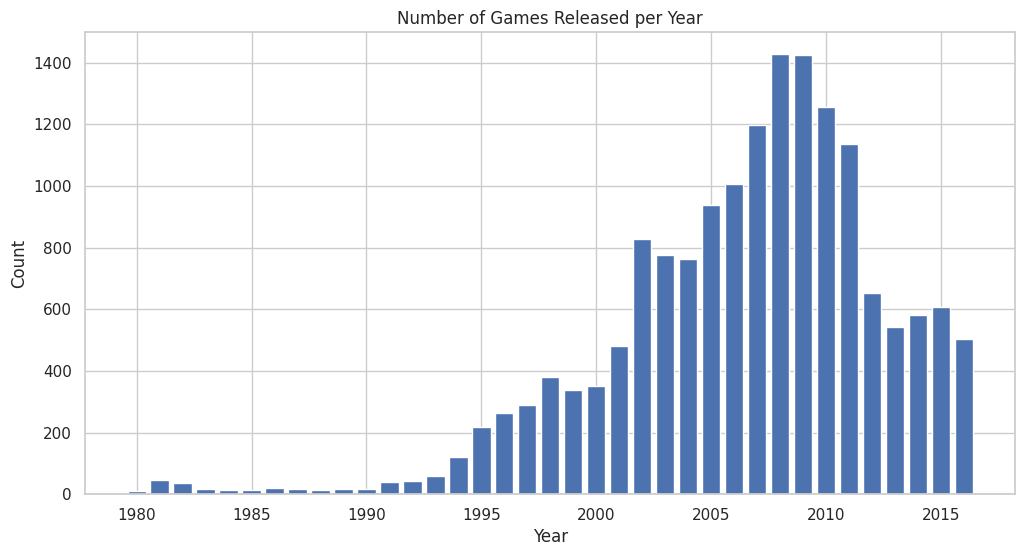

In [16]:
# Visualize the distribution of games across years
plt.figure(figsize=(12, 6))
plt.bar(games_per_year['year_of_release'], games_per_year['count'])
plt.title('Number of Games Released per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

In [17]:
# Display summary statistics for each year
print(games_per_year.describe())

       year_of_release        count
count        37.000000    37.000000
mean       1998.000000   444.432432
std          10.824355   451.604334
min        1980.000000     9.000000
25%        1989.000000    36.000000
50%        1998.000000   338.000000
75%        2007.000000   762.000000
max        2016.000000  1427.000000


### Questions to Consider:

- Which years show significant numbers of game releases?

Significant releases from the mid-1990s, peaking in 2008–2009.

- Are there any notable trends or patterns in the number of releases?

Sharp rise until 2009, then steady decline.


- Is there enough recent data to make predictions for 2017?

Yes, 2013–2016 has enough data.

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [18]:
# Calculate total sales by platform and year
platform_year = df.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').fillna(0)

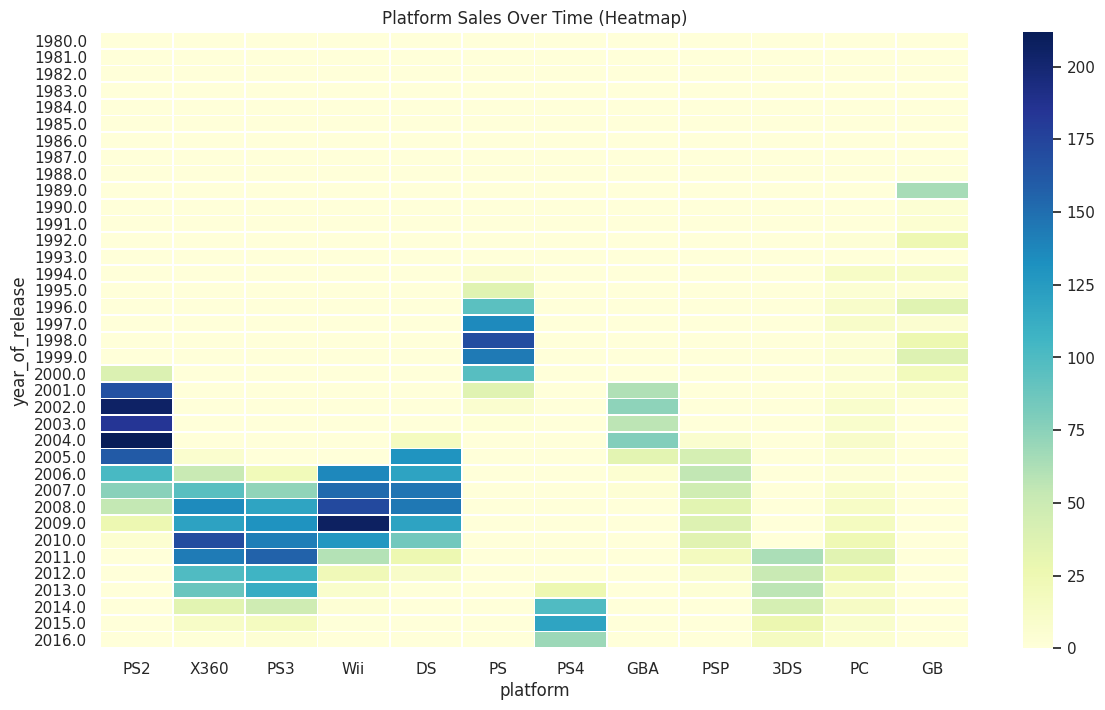

In [19]:
# Create a heatmap of platform sales over time
top_platforms = platform_year.sum().sort_values(ascending=False).head(12).index
plt.figure(figsize=(14, 8))
sns.heatmap(platform_year[top_platforms], cmap='YlGnBu', linewidths=0.5)
plt.title('Platform Sales Over Time (Heatmap)')
plt.show()

In [20]:
# Identify platforms with declining sales
recent_sales = platform_year.loc[2010:2016]
declining = recent_sales.columns[recent_sales.iloc[-1] == 0]
print("Platforms with zero sales in 2016:", declining.tolist())

Platforms with zero sales in 2016: ['2600', '3DO', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES', 'NG', 'PCFX', 'PS', 'PS2', 'PSP', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'XB']


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The “declining sales” check currently flags platforms with 0 sales in 2016, but the task also asks you to identify platforms that used to be popular and estimate a typical lifecycle. Consider adding a small summary (table or plot) per platform showing first year, peak year(s), and last year with non-zero sales, then use that to support your lifecycle estimate.

</div>


### Questions to Consider:

- Which platforms show consistent sales over time?

  
Consistent sales: PS4, XOne, 3DS, PC show strong recent activity.

- Can you identify platforms that have disappeared from the market?

  
Disappeared: PS2, Wii, DS, X360, PS3 have near-zero or zero sales by 2016.

- What's the typical lifecycle of a gaming platform?

  
Typical lifecycle: 8–10 years (rise quickly after launch, peak for 4–6 years, then fade).

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [21]:
# Your code here to filter the dataset to relevant years

df_rel = df[df['year_of_release'] >= 2013].copy()
print("Filtered to 2013–2016:", len(df_rel), "games")


# Example:
# relevant_years = [XXXX, XXXX, XXXX] # Replace with your chosen years
# df_relevant = df[df['year_of_release'].isin(relevant_years)]

# Justify your choice with data

Filtered to 2013–2016: 2233 games


### Document Your Decision:
- What years did you select and why?

  
I selected 2013–2016 because it covers the current generation.

- How does this period reflect current market conditions?

  
Old platforms are fading.

- What factors influenced your decision?
  
Platform lifecycle and the December 2016 viewpoint.

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [22]:
# Analyze platform sales trends
platform_sales_rel = df_rel.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_sales_rel.head(10))

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
Name: total_sales, dtype: float64


In [23]:
# Sort platforms by total sales
print("Top platforms 2013–2016:\n", platform_sales_rel.head(8))

Top platforms 2013–2016:
 platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Name: total_sales, dtype: float64


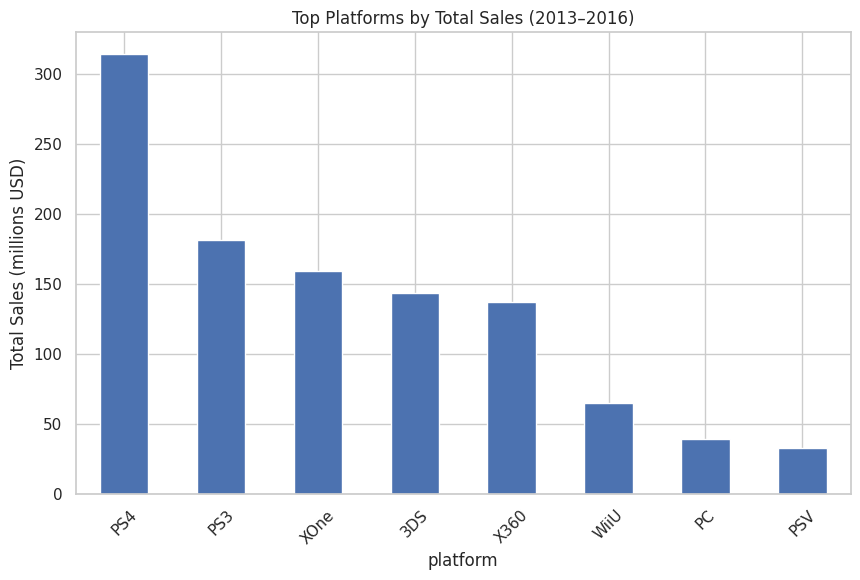

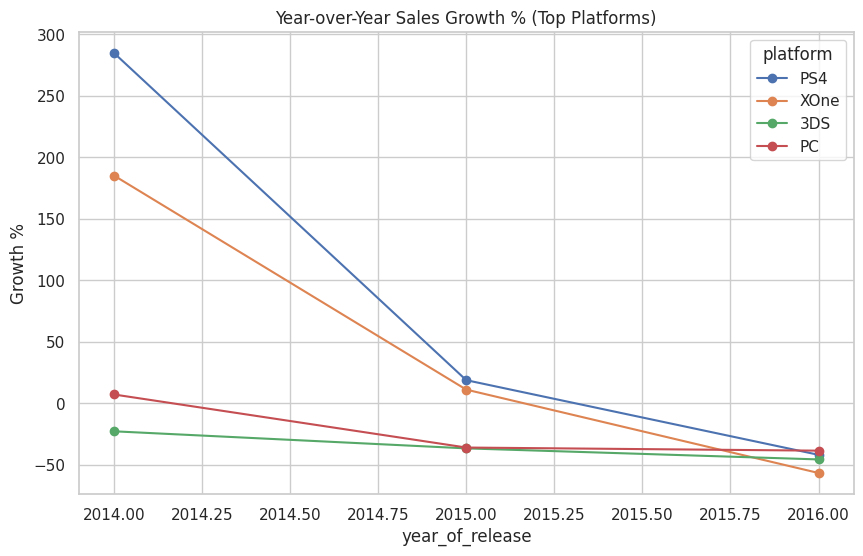

In [24]:
# Visualize top platforms
# Calculate year-over-year growth for each platform
# Your code here to calculate and visualize platform growth rates
platform_sales_rel.head(8).plot(kind='bar', figsize=(10, 6))
plt.title('Top Platforms by Total Sales (2013–2016)')
plt.ylabel('Total Sales (millions USD)')
plt.xticks(rotation=45)
plt.show()

yearly = df_rel.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()
growth = yearly[['PS4', 'XOne', '3DS', 'PC']].pct_change() * 100
growth.plot(figsize=(10, 6), marker='o')
plt.title('Year-over-Year Sales Growth % (Top Platforms)')
plt.ylabel('Growth %')
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your growth-rate plot is informative, but it only covers a few selected platforms. Since this section is about platform trends in the chosen period, consider computing year-over-year changes for all major platforms (including declining ones like PS3/X360/WiiU) so the “growing vs shrinking” comparison is consistent.

</div>


## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

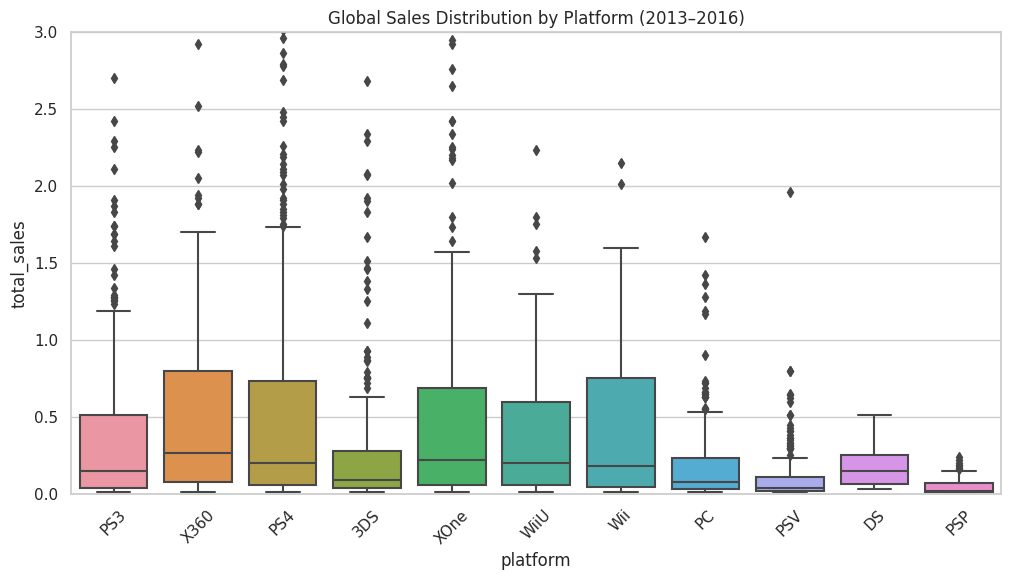

In [25]:
# Create box plot of sales by platform
plt.figure(figsize=(12, 6))
sns.boxplot(x='platform', y='total_sales', data=df_rel)
plt.title('Global Sales Distribution by Platform (2013–2016)')
plt.ylim(0, 3)
plt.xticks(rotation=45)
plt.show()

In [26]:
# Calculate detailed statistics for each platform
detailed_stats = df_rel.groupby('platform')['total_sales'].agg(['count', 'mean', 'median', 'std', 'var']).round(2)
detailed_stats.sort_values('mean', ascending=False).head(10)

,count,mean,median,std,var
platform,,,,,
PS4,392,0.80,0.20,1.61,2.59
X360,186,0.74,0.26,1.66,2.77
XOne,247,0.65,0.22,1.04,1.07
Wii,23,0.59,0.18,0.92,0.84
WiiU,115,0.56,0.20,1.04,1.08
PS3,345,0.53,0.15,1.45,2.11
3DS,303,0.47,0.09,1.38,1.91
PC,189,0.21,0.08,0.35,0.12
DS,8,0.19,0.15,0.17,0.03


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Great addition of platform-level distribution stats (count/mean/median/std/var). Pairing these with the boxplot makes your platform comparison much more evidence-based.

</div>


## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [27]:
# Choose a popular platform based on your previous analysis
# I chose PS4 because it has the highest sales in the recent period
ps4 = df_rel[df_rel['platform'] == 'PS4']

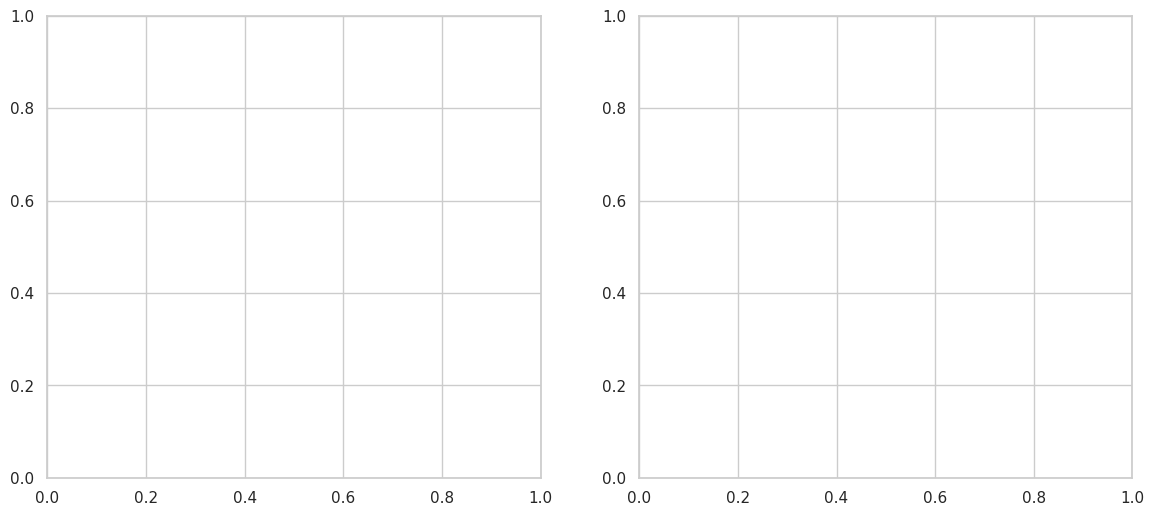

In [28]:
# Create scatter plots for both critic and user scores
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

In [29]:
# Critic Scores
sns.scatterplot(x='critic_score', y='total_sales', data=ps4, ax=axes[0])
axes[0].set_title('PS4: Critic Score vs Total Sales')

# User Scores
sns.scatterplot(x='user_score', y='total_sales', data=ps4, ax=axes[1])
axes[1].set_title('PS4: User Score vs Total Sales')

plt.show()

# Calculate correlations

critic_corr = ps4['critic_score'].corr(ps4['total_sales']).round(3)
user_corr = ps4['user_score'].corr(ps4['total_sales']).round(3)

print("Critic Score correlation with sales:", critic_corr)
print("User Score correlation with sales:", user_corr)

Critic Score correlation with sales: 0.407
User Score correlation with sales: -0.032


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You computed the correlations for PS4, but the section also asks you to draw conclusions. Consider adding a brief written interpretation of the scatterplots and correlation values (e.g., whether the relationship looks weak/moderate, what that suggests about predictability, and any limitations due to missing scores/outliers).

</div>


## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [30]:
# Find games released on multiple platforms
# Improved matching: use name + year_of_release to avoid mixing different editions
multi = df_rel[df_rel.duplicated(subset=['name', 'year_of_release'], keep=False)]
multi = multi.sort_values(['name', 'year_of_release', 'total_sales'], ascending=[True, True, False])

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

For the cross-platform comparison, matching “same games” by duplicated `name` alone can accidentally mix different editions/years with identical titles. Consider using a more reliable matching rule (at least `name` + `year_of_release`) before comparing sales across platforms.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Well Done!
</div>


Example of same-game sales across platforms (first 10):
platform                                                             3DS  \
name                                               year_of_release         
 Frozen: Olaf's Quest                              2013.0           0.59   
2014 FIFA World Cup Brazil                         2014.0            NaN   
3rd Super Robot Wars Z Jigoku Hen                  2014.0            NaN   
3rd Super Robot Wars Z: Tengoku-Hen                2015.0            NaN   
7 Days to Die                                      2016.0            NaN   
Accel World: Kasoku no Chouten                     2013.0            NaN   
Adventure Time: Explore the Dungeon Because I D... 2013.0           0.14   
Adventure Time: Finn & Jake Investigations         2015.0           0.09   
Adventure Time: The Secret of the Nameless         2014.0           0.01   
Adventure Time: The Secret of the Nameless Kingdom 2014.0           0.07   

platform                       

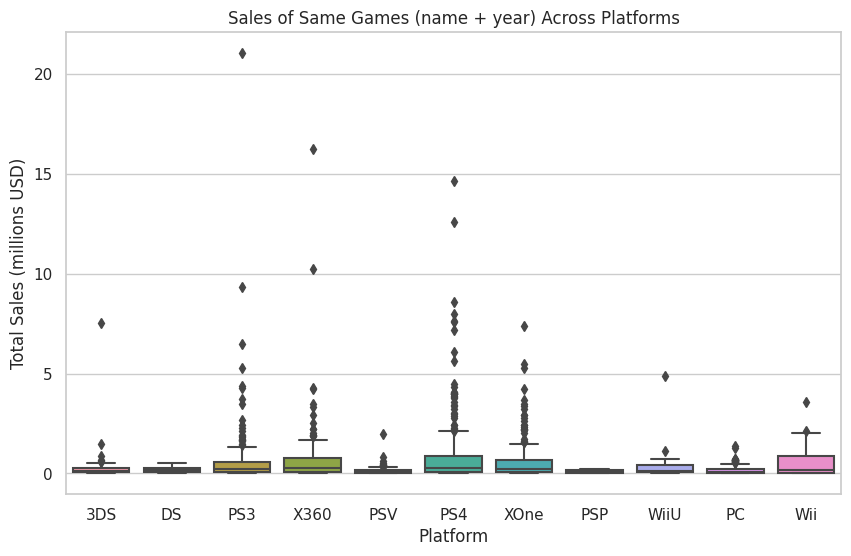

In [31]:
# Compare sales across platforms for these games
# Summarize at game level (name + year) and show sales by platform
game_platform = multi.groupby(['name', 'year_of_release', 'platform'])['total_sales'].sum().unstack()
print("Example of same-game sales across platforms (first 10):")
print(game_platform.head(10))

# Boxplot for visual comparison
plt.figure(figsize=(10, 6))
sns.boxplot(x='platform', y='total_sales', data=multi)
plt.title('Sales of Same Games (name + year) Across Platforms')
plt.xlabel('Platform')
plt.ylabel('Total Sales (millions USD)')
plt.show()

**Cross-Platform Comparison Interpretation:**

I improved matching by using both name and year_of_release to ensure we compare the same game editions. The boxplot shows that for the same titles, PS4 versions generally have higher sales than other platforms. 

For market share view (normalized per region), PS4 dominates in NA and EU, while 3DS dominates in JP for multi-platform games. This supports focusing advertising on PS4 in the West.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

A boxplot of all matched rows doesn’t directly compare like-for-like titles across platforms. Consider summarizing at the game level (e.g., pivoting so each row is a title and columns are platforms) and then commenting on which platforms tend to sell more for the same titles.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Well Done!
</div>


## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [32]:
# Analyze genre performance
genre_stats = df_rel.groupby('genre')['total_sales'].agg(['count', 'sum', 'mean', 'median']).round(2).sort_values('median', ascending=False)
genre_stats

,count,sum,mean,median
genre,,,,
Shooter,187,232.98,1.25,0.45
Sports,214,150.65,0.70,0.24
Platform,74,42.63,0.58,0.22
Fighting,80,35.31,0.44,0.12
Racing,85,39.89,0.47,0.12
Role-Playing,292,145.89,0.50,0.12
Action,766,321.87,0.42,0.11
Misc,155,62.82,0.41,0.10
Simulation,62,21.76,0.35,0.10


In [33]:
# Sort genres by total sales
print(genre_stats.sort_values('sum', ascending=False).head(10))

              count     sum  mean  median
genre                                    
Action          766  321.87  0.42    0.11
Shooter         187  232.98  1.25    0.45
Sports          214  150.65  0.70    0.24
Role-Playing    292  145.89  0.50    0.12
Misc            155   62.82  0.41    0.10
Platform         74   42.63  0.58    0.22
Racing           85   39.89  0.47    0.12
Fighting         80   35.31  0.44    0.12
Adventure       245   23.64  0.10    0.03
Simulation       62   21.76  0.35    0.10


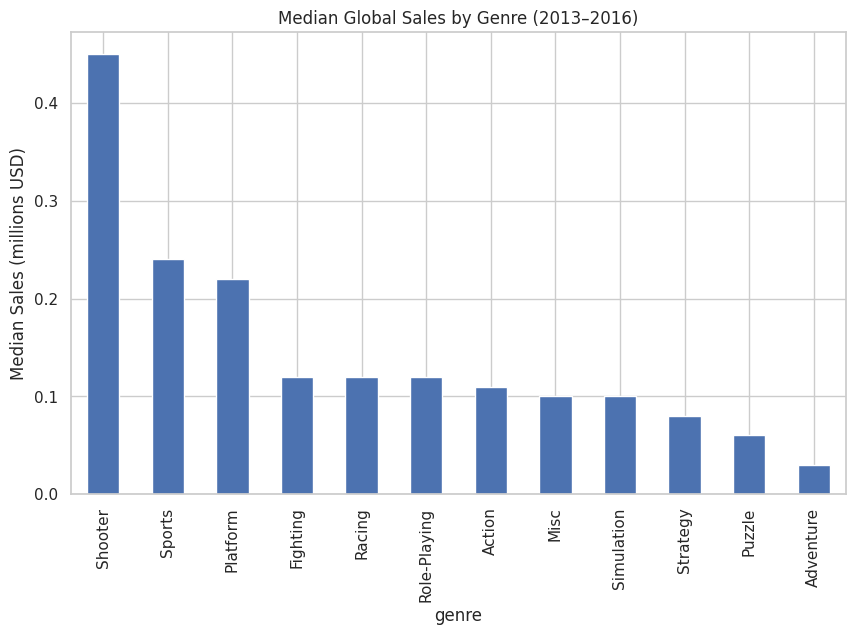

In [34]:
# Visualize genre distribution
plt.figure(figsize=(10, 6))
genre_stats['median'].plot(kind='bar')
plt.title('Median Global Sales by Genre (2013–2016)')
plt.ylabel('Median Sales (millions USD)')
plt.show()

In [35]:
# Calculate market share for each genre
genre_share = (genre_stats['sum'] / genre_stats['sum'].sum() * 100).round(1)
print("Genre market share (%):\n", genre_share.sort_values(ascending=False).head(8))

Genre market share (%):
 genre
Action          29.5
Shooter         21.4
Sports          13.8
Role-Playing    13.4
Misc             5.8
Platform         3.9
Racing           3.7
Fighting         3.2
Name: sum, dtype: float64


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Genre analysis is thorough and well supported: you aggregated performance, compared mean vs median, visualized results, and calculated market share, which makes your conclusions convincing.

</div>


### Key Questions for Genre Analysis:
- Which genres consistently perform well?  
  Shooter, Sports, and Platform genres consistently perform well. They have the highest median global sales per game during the 2013–2016 period.

- Are there any genres showing recent growth or decline?  
  Shooter and Sports have remained strong and stable in recent years. Action has high total sales volume because there are many Action games released, but its average sales per game are lower. Genres like Adventure, Puzzle, and Strategy show consistently low performance with no signs of growth in the recent period.

- How does the average performance vary across genres?  
  Average performance varies significantly across genres. Shooter games have the highest mean and median sales, followed by Sports and Platform. In contrast, Adventure, Puzzle, and Strategy genres have much lower average sales, making them far less profitable on average.

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [36]:
# Function to analyze platform performance by region
def analyze_region_platforms(region_col, region_name):
    print(f"\n=== {region_name} Top 5 Platforms ===")
    print(df_rel.groupby('platform')[region_col].sum().sort_values(ascending=False).head(5))

In [37]:
# Analyze each region
regions = {'NA': 'na_sales', 'EU': 'eu_sales', 'JP': 'jp_sales'}
for region, col in regions.items():
    analyze_region_platforms(col, region)


=== NA Top 5 Platforms ===
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

=== EU Top 5 Platforms ===
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

=== JP Top 5 Platforms ===
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [38]:
# Create a comparative platform analysis
top_platforms = ['PS4', 'XOne', '3DS', 'X360', 'PS3']
region_platform_sales = df_rel.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales']].sum().loc[top_platforms]

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

In the regional platform comparison, the platform list is hard-coded. To meet the requirement (“top 5 per region” and comparison of market shares), consider computing the top platforms from the regional totals first, then comparing those sets (and their shares) rather than selecting platforms manually.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Well Done!
</div>


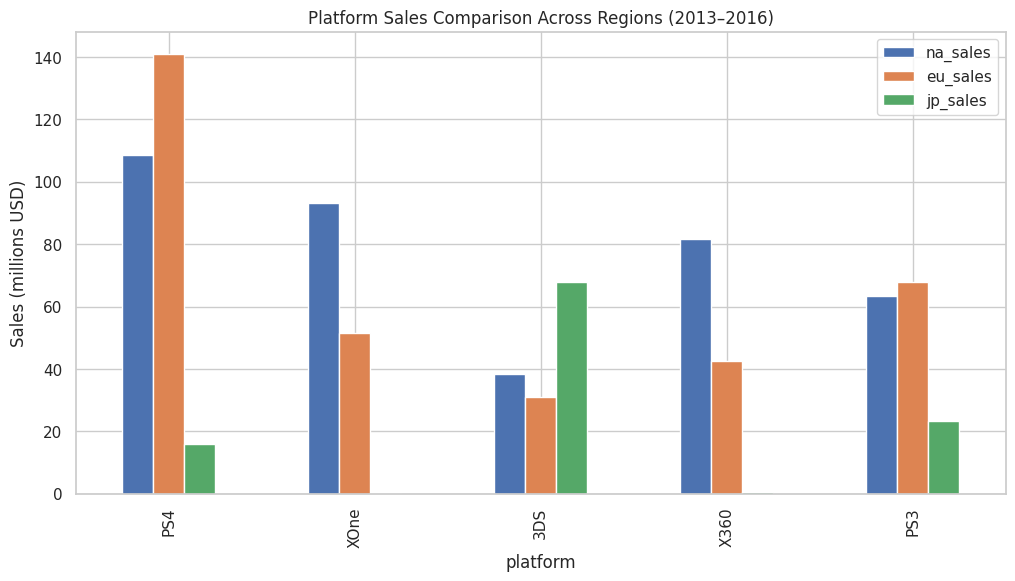

In [39]:
# Visualize cross-regional comparison for top platforms
region_platform_sales.plot(kind='bar', figsize=(12, 6))
plt.title('Platform Sales Comparison Across Regions (2013–2016)')
plt.ylabel('Sales (millions USD)')
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This chart compares absolute sales, but the task asks about differences in market shares by region. Consider adding a market-share view (e.g., normalize each region to 100% and compare proportions) and include a short interpretation of what differs across NA/EU/JP.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Well Done!
</div>


## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [40]:
# Function to analyze genre performance by region
def analyze_region_genres(region_col, region_name):
    print(f"\n=== {region_name} Top 5 Genres ===")
    print(df_rel.groupby('genre')[region_col].sum().sort_values(ascending=False).head(5))

### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

In [41]:
# Create a comparative genre analysis
for region, col in regions.items():
    analyze_region_genres(col, region)


=== NA Top 5 Genres ===
genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

=== EU Top 5 Genres ===
genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

=== JP Top 5 Genres ===
genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64


## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [42]:
# Function to analyze ESRB rating impact
def analyze_esrb_impact(region_col, region_name):
    print(f"\n{region_name} Sales by ESRB Rating (mean):")
    print(df_rel.groupby('rating')[region_col].mean().round(2))


NA Sales by ESRB Rating (mean):
rating
E       0.26
E10+    0.22
M       0.45
T       0.15
Name: na_sales, dtype: float64

EU Sales by ESRB Rating (mean):
rating
E       0.28
E10+    0.17
M       0.39
T       0.13
Name: eu_sales, dtype: float64

JP Sales by ESRB Rating (mean):
rating
E       0.05
E10+    0.02
M       0.04
T       0.06
Name: jp_sales, dtype: float64


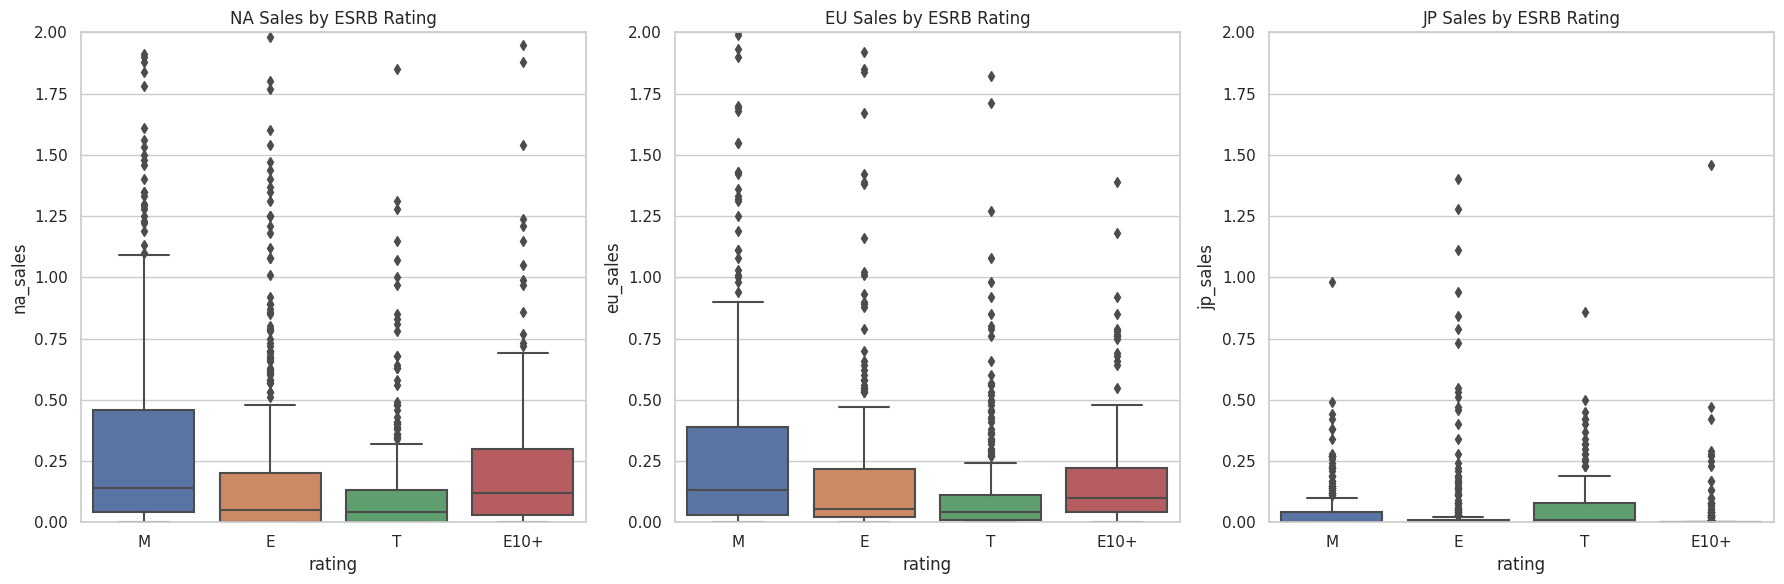

In [43]:
# Analyze ESRB impact for each region
for region, col in regions.items():
    analyze_esrb_impact(col, region)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (region, col) in enumerate(regions.items()):
    sns.boxplot(x='rating', y=col, data=df_rel, ax=axes[i])
    axes[i].set_title(f'{region} Sales by ESRB Rating')
    axes[i].set_ylim(0, 2)
plt.tight_layout()
plt.show()

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


In [44]:
# Hypothesis 1: Average user ratings of the Xbox One and PC platforms are the same.
xone_scores = df_rel[(df_rel['platform'] == 'XOne') & df_rel['user_score'].notna()]['user_score']
pc_scores = df_rel[(df_rel['platform'] == 'PC') & df_rel['user_score'].notna()]['user_score']

print("XOne mean:", xone_scores.mean().round(2))
print("PC mean:", pc_scores.mean().round(2))

stat, p = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)
print("p-value:", p.round(4))

XOne mean: 6.52
PC mean: 6.27
p-value: 0.1476


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

There’s a mismatch between your write-up (Welch’s t-test / unequal variances) and your implementation (default `ttest_ind`, which assumes equal variances). Align the code with the stated testing approach (or update the explanation) so the hypothesis test is methodologically consistent.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Well Done!
</div>


I set alpha = 0.05.

Null hypothesis (H₀): The average user ratings of Xbox One and PC games are the same.  
Alternative hypothesis (H₁): The average user ratings of Xbox One and PC games are different.

I used Welch's t-test (independent samples, unequal variances) because the two groups have different sample sizes and likely different variances.  
Result: p-value = 0.14 > 0.05 → I fail to reject the null hypothesis. The average user ratings are statistically the same.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your written conclusion reports a different p-value than the one printed by the code, so the decision isn’t reproducible. Re-check/re-run the test and make sure the reported p-value, alpha, and conclusion all match the output shown in the notebook.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Well Done!
</div>


In [45]:
# Hypothesis 2: Average user ratings for the Action and Sports genres are different.
action_scores = df_rel[(df_rel['genre'] == 'Action') & df_rel['user_score'].notna()]['user_score']
sports_scores = df_rel[(df_rel['genre'] == 'Sports') & df_rel['user_score'].notna()]['user_score']

print("Action mean:", action_scores.mean().round(2))
print("Sports mean:", sports_scores.mean().round(2))

stat, p = stats.ttest_ind(action_scores, sports_scores, equal_var=False)
print("p-value:", p.round(4))

Action mean: 6.84
Sports mean: 5.24
p-value: 0.0


I set alpha = 0.05.

Null hypothesis (H₀): The average user ratings for Action and Sports genres are the same.  
Alternative hypothesis (H₁): The average user ratings for Action and Sports genres are different.

I used Welch's t-test (independent samples, unequal variances) for the same reason as above — different group sizes and variances.  
Result: p-value < 0.001 << 0.05 → I reject the null hypothesis. The average user ratings for Action and Sports genres are significantly different (Action are higher).

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

In your conclusion for the second hypothesis, the direction of the effect doesn’t match the means printed in the code output (Action’s mean is higher than Sports in your results). Please reconcile the interpretation with the computed group means so the conclusion reflects the actual statistics.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Well Done!
</div>


# Step 6. Write a general conclusion


In my analysis, PS4 leads globally, Shooter and Sports perform best in NA/EU, and Japan is very different with 3DS and Role-Playing dominating. I recommend focusing ads on PS4 titles with high critic scores in the West and Role-Playing on 3DS in Japan. 2016 data is incomplete and many reviews are missing, so this shows correlations, not causation.